# Download (response size) sweep — MPC vs Proxy, native + browser

Fixed: 100 Mbps, 25 ms latency, 1 KB request.
Variable: response size (1-51 KB).

Reads `metrics_native.csv` and `metrics_browser.csv` from this directory and writes `download_light.svg` / `download_dark.svg`.

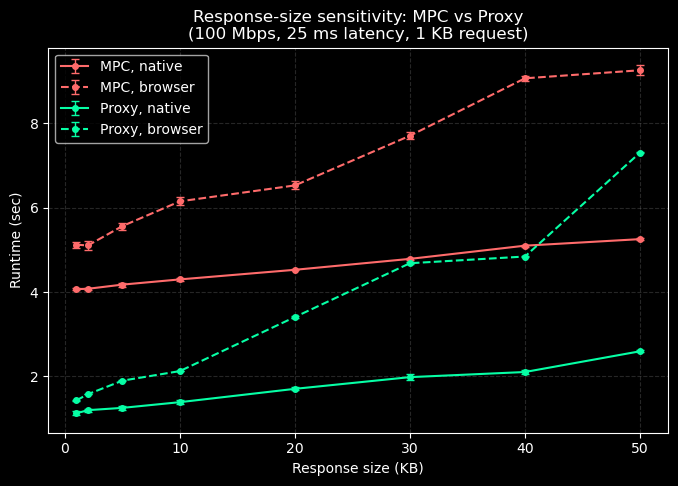

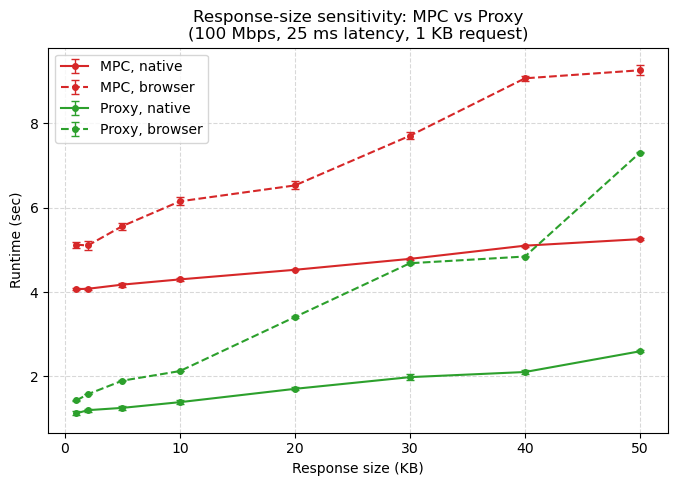

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

NATIVE  = "metrics_native.csv"
BROWSER = "metrics_browser.csv"

SERIES = [
    (NATIVE,  "download_sweep_mpc",    "MPC, native",         "#ff6b6b",   "#d62728",   "-"),
    (BROWSER, "download_sweep_mpc",    "MPC, browser",        "#ff6b6b",   "#d62728",   "--"),
    (NATIVE,  "download_sweep_proxy",  "Proxy, native",       "#06ffa5",   "#2ca02c",   "-"),
    (BROWSER, "download_sweep_proxy",  "Proxy, browser",      "#06ffa5",   "#2ca02c",   "--"),
]

for dark in [True, False]:
    plt.style.use("dark_background" if dark else "default")
    fig, ax = plt.subplots(figsize=(8, 5))
    for csv, group, label, dc, lc, ls in SERIES:
        df = pd.read_csv(csv)
        df = df[df["group"] == group]
        agg = df.groupby("download_size")["time_total"].agg(["mean", "std"]).reset_index()
        agg["std"] = agg["std"].fillna(0)
        ax.errorbar(
            agg["download_size"] / 1024.0,
            agg["mean"] / 1000.0,
            yerr=agg["std"] / 1000.0,
            label=label,
            color=(dc if dark else lc),
            linestyle=ls,
            marker="o",
            markersize=4,
            capsize=3,
            capthick=1,
            elinewidth=1,
        )

    ax.set_xlabel("Response size (KB)")
    ax.set_ylabel("Runtime (sec)")
    ax.set_title("Response-size sensitivity: MPC vs Proxy\n(100 Mbps, 25 ms latency, 1 KB request)")
    ax.grid(True, linestyle="--", color="gray", alpha=0.3)
    ax.legend(loc="upper left")

    out = "download_dark.svg" if dark else "download_light.svg"
    plt.savefig(out, bbox_inches="tight")
    plt.show()
